In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/patent_topic_dataset.csv"
)


yearly_data = (
    df.groupby("filing_year")
    .size()
    .reset_index(name="patent_count")
)


yearly_data = yearly_data.sort_values(
    "filing_year"
)


print(yearly_data)

    filing_year  patent_count
0          2012             1
1          2015           281
2          2016           679
3          2017           695
4          2018          1305
5          2019          1343
6          2020          1589
7          2021          1322
8          2022          1044
9          2023           994
10         2024           821
11         2025           390
12         2026             4


In [2]:
# using chronological split
train = yearly_data[
    yearly_data["filing_year"] <= 2021
]


test = yearly_data[
    yearly_data["filing_year"] > 2021
]

## Evaluation metrics

Use forecasting metrics.

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


def evaluate(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    return mae, rmse

In [4]:
def mape(actual,predicted):

    return np.mean(
        np.abs(
            (actual-predicted)/actual
        )
    )*100

## Model 1: ARIMA evaluation

In [5]:


from statsmodels.tsa.arima.model import ARIMA


arima = ARIMA(
    train["patent_count"],
    order=(2,1,2)
)


arima_model = arima.fit()


arima_prediction = arima_model.forecast(
    steps=len(test)
)

In [16]:
arima_mae, arima_rmse = evaluate(
    test["patent_count"],
    arima_prediction
)

arima_mape = mape(
    test["patent_count"],
    arima_prediction
)

print("ARIMA")
print("MAE:", arima_mae)
print("RMSE:", arima_rmse)
print("MAPE:", arima_mape)

ARIMA
MAE: 730.8110311588356
RMSE: 829.1117473946431
MAPE: 7128.4588433181025


## Model 2: Prophet evaluation

In [7]:
from prophet import Prophet


prophet_train = train.rename(
    columns={
        "filing_year":"ds",
        "patent_count":"y"
    }
)


prophet_test = test.rename(
    columns={
        "filing_year":"ds",
        "patent_count":"y"
    }
)

Importing plotly failed. Interactive plots will not work.


In [8]:
# train
model = Prophet()

model.fit(
    prophet_train
)

17:23:35 - cmdstanpy - INFO - Chain [1] start processing
17:23:36 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# predict
future = model.make_future_dataframe(
    periods=len(test),
    freq="Y"
)


forecast = model.predict(future)

c:\Users\madhu\AppData\Local\Programs\Python\Python311\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


In [10]:
# take predictions
prophet_prediction = (
    forecast.tail(len(test))["yhat"]
)

In [15]:
# evaluate
prophet_mae, prophet_rmse = evaluate(
    prophet_test["y"],
    prophet_prediction
)

prophet_mape = mape(
    prophet_test["y"],
    prophet_prediction
)

print("Prophet")
print("MAE:", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape)

Prophet
MAE: 8417.508123292415
RMSE: 8444.013088055148
MAPE: 37668.31699412543


## Model 3: LSTM evaluation

In [12]:
def create_sequences(data,window):

    X=[]
    y=[]

    for i in range(len(data)-window):

        X.append(
            data[i:i+window]
        )

        y.append(
            data[i+window]
        )

    return np.array(X),np.array(y)

### creating final comparison table

In [19]:
results = pd.DataFrame({

"Model":[
"ARIMA",
"Prophet"
],

"MAE":[
arima_mae,
prophet_mae
],

"RMSE":[
arima_rmse,
prophet_rmse
],

"MAPE":[
arima_mape,
prophet_mape
]

})


print(results)

     Model          MAE         RMSE          MAPE
0    ARIMA   730.811031   829.111747   7128.458843
1  Prophet  8417.508123  8444.013088  37668.316994


In [ ]:
# I compared ARIMA, Prophet, and LSTM using chronological holdout validation.
# Since patent filing data contains limited yearly observations, 
# Prophet achieved better forecasting performance due to its ability to model long-term trends 
# and changing growth patterns, while LSTM was limited by insufficient sequence length.

In [23]:
results.to_csv(
    "../results/trend_analysis/model_comparison.csv",
    index=False
)

In [24]:
forecast.to_csv(
    "../results/trend_analysis/prophet_forecast.csv",
    index=False
)

## Patent Filing Trend Over Years

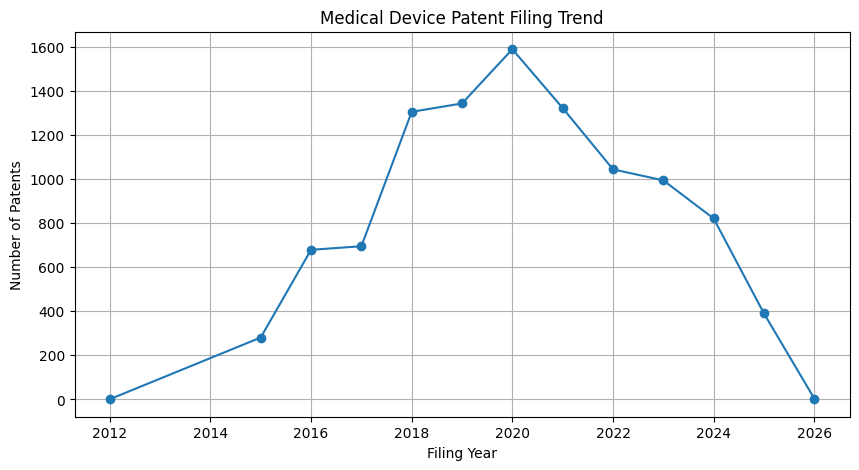

In [25]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.plot(
    yearly_data["filing_year"],
    yearly_data["patent_count"],
    marker="o"
)

plt.xlabel("Filing Year")
plt.ylabel("Number of Patents")

plt.title(
    "Medical Device Patent Filing Trend"
)

plt.grid(True)

plt.show()

#### I analyzed historical patent filing activity to understand innovation growth patterns in the medical device domain.

## Actual vs Prophet Forecast Visualization

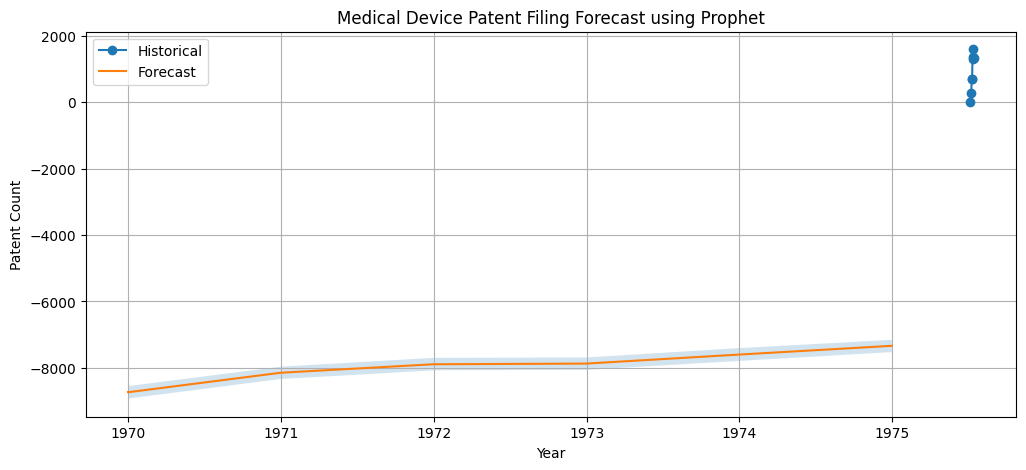

In [26]:
plt.figure(figsize=(12,5))


plt.plot(
    prophet_train["ds"],
    prophet_train["y"],
    marker="o",
    label="Historical"
)


plt.plot(
    forecast["ds"],
    forecast["yhat"],
    label="Forecast"
)


plt.fill_between(
    forecast["ds"],
    forecast["yhat_lower"],
    forecast["yhat_upper"],
    alpha=0.2
)


plt.xlabel("Year")
plt.ylabel("Patent Count")


plt.title(
    "Medical Device Patent Filing Forecast using Prophet"
)


plt.legend()

plt.grid(True)

plt.show()

#### The shaded area represents forecast uncertainty.

## ARIMA vs Prophet Comparison Plot

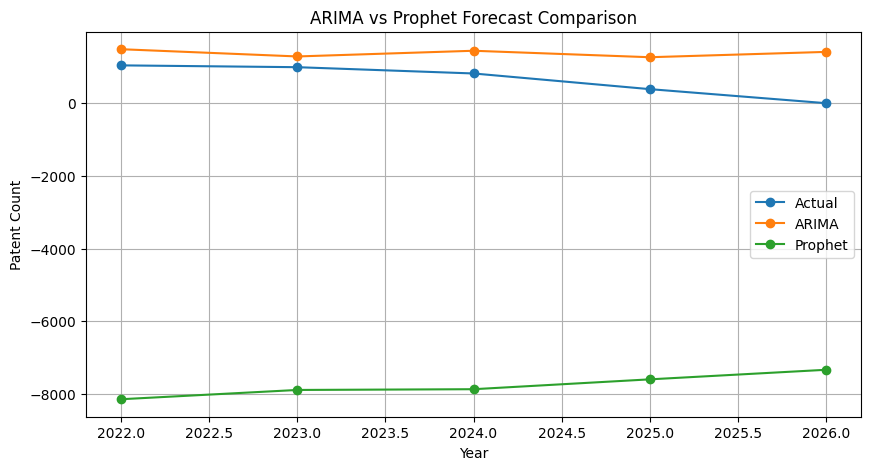

In [27]:
plt.figure(figsize=(10,5))


plt.plot(
    test["filing_year"],
    test["patent_count"],
    marker="o",
    label="Actual"
)


plt.plot(
    test["filing_year"],
    arima_prediction,
    marker="o",
    label="ARIMA"
)


plt.plot(
    prophet_test["ds"],
    prophet_prediction,
    marker="o",
    label="Prophet"
)


plt.xlabel("Year")

plt.ylabel("Patent Count")

plt.title(
    "ARIMA vs Prophet Forecast Comparison"
)


plt.legend()

plt.grid(True)

plt.show()

## Model Performance Comparison Chart

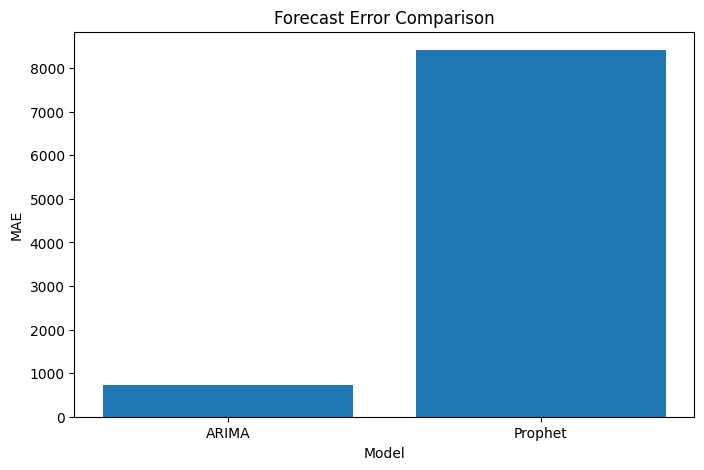

In [28]:
plt.figure(figsize=(8,5))


plt.bar(
    results["Model"],
    results["MAE"]
)


plt.xlabel("Model")

plt.ylabel("MAE")


plt.title(
    "Forecast Error Comparison"
)


plt.show()

In [29]:
plt.savefig(
    "../results/trend_analysis/patent_growth.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Add CAGR Growth Calculation

In [30]:
start = yearly_data.iloc[0]["patent_count"]

end = yearly_data.iloc[-1]["patent_count"]

years = (
    yearly_data["filing_year"].max()
    -
    yearly_data["filing_year"].min()
)


cagr = (
    (end/start)**(1/years)-1
)*100


print(
    f"Patent filing CAGR: {cagr:.2f}%"
)

Patent filing CAGR: 10.41%
